<a href="https://colab.research.google.com/github/Udayps2303/Deepfake-Detection/blob/main/Deepfake_VGG_16.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -q tensorflow kagglehub opencv-python matplotlib scikit-learn

# Setting Path

In [ ]:
import kagglehub

dataset_path = kagglehub.dataset_download(
    "xhlulu/140k-real-and-fake-faces"
)

print("DATASET PATH:", dataset_path)
import os

BASE_DIR = "/kaggle/input/140k-real-and-fake-faces/real_vs_fake/real-vs-fake"

train_dir = os.path.join(BASE_DIR, "train")
valid_dir = os.path.join(BASE_DIR, "valid")
test_dir  = os.path.join(BASE_DIR, "test")

print(os.listdir(train_dir))
print(os.listdir(valid_dir))
print(os.listdir(test_dir))


Using Colab cache for faster access to the '140k-real-and-fake-faces' dataset.
DATASET PATH: /kaggle/input/140k-real-and-fake-faces
['fake', 'real']
['fake', 'real']
['fake', 'real']


# Copying data to make a smaller Dataset

In [ ]:
import os
import shutil
import random
from tqdm import tqdm  # specific library for progress bars

# --- Configuration ---
# The read-only source directory
SOURCE_BASE_DIR = "/kaggle/input/140k-real-and-fake-faces/real_vs_fake/real-vs-fake"

# The new writable destination directory
DEST_BASE_DIR = "/kaggle/working/subset_dataset"

# How many images you want per class (Real/Fake) for each split
LIMITS = {
    "train": 20000,
    "valid": 5000,
    "test":  5000
}

CLASSES = ["real", "fake"]

# --- Execution ---
def create_subset():
    # Loop through each split (train, valid, test)
    for split, limit in LIMITS.items():
        for label in CLASSES:
            source_dir = os.path.join(SOURCE_BASE_DIR, split, label)
            dest_dir = os.path.join(DEST_BASE_DIR, split, label)

            # Create the destination folder structure
            os.makedirs(dest_dir, exist_ok=True)

            # Get list of all images
            try:
                files = os.listdir(source_dir)
            except FileNotFoundError:
                print(f"Source directory not found: {source_dir}")
                continue

            # Shuffle to ensure a random selection (optional but recommended)
            random.seed(42) # Set seed for reproducibility
            random.shuffle(files)

            # Slice the list to the desired limit
            selected_files = files[:limit]

            print(f"Processing {split}/{label}: Copying {len(selected_files)} images...")

            # Copy files to the new destination
            for filename in tqdm(selected_files):
                src_file = os.path.join(source_dir, filename)
                dst_file = os.path.join(dest_dir, filename)
                shutil.copy(src_file, dst_file)

    print("\n--- Subset creation complete! ---")
    print(f"New dataset location: {DEST_BASE_DIR}")

# Run the function
if __name__ == "__main__":
    create_subset()

    # Verify the counts
    print("\nVerifying counts in new dataset:")
    for split in LIMITS.keys():
        for label in CLASSES:
            path = os.path.join(DEST_BASE_DIR, split, label)
            if os.path.exists(path):
                print(f"{split}/{label}: {len(os.listdir(path))} images")

Processing train/real: Copying 20000 images...


100%|██████████| 20000/20000 [01:17<00:00, 256.57it/s]


Processing train/fake: Copying 20000 images...


100%|██████████| 20000/20000 [01:21<00:00, 245.53it/s]


Processing valid/real: Copying 5000 images...


...

Processing test/real: Copying 5000 images...


100%|██████████| 5000/5000 [00:17<00:00, 294.09it/s]


Processing test/fake: Copying 5000 images...


100%|██████████| 5000/5000 [00:18<00:00, 265.55it/s]


--- Subset creation complete! ---
New dataset location: /kaggle/working/subset_dataset

Verifying counts in new dataset:
train/real: 20000 images
train/fake: 20000 images
valid/real: 5000 images
valid/fake: 5000 images
test/real: 5000 images
test/fake: 5000 images


# Setting up the Directory

In [ ]:
# Define the new base directory where the sliced data lives
BASE_DIR = "/kaggle/working/subset_dataset"

# Re-assign the original variable names to point to the new locations
train_dir = os.path.join(BASE_DIR, "train")
valid_dir = os.path.join(BASE_DIR, "valid")
test_dir  = os.path.join(BASE_DIR, "test")

# Verify the changes
print("New Directory Paths:")
print("Train:", train_dir)
print("Valid:", valid_dir)
print("Test: ", test_dir)

# Verify the contents exist (Quick Check)
print("\nCheck if directories exist:")
print(f"Train exists: {os.path.exists(train_dir)}")
print(f"Valid exists: {os.path.exists(valid_dir)}")
print(f"Test exists:  {os.path.exists(test_dir)}")

New Directory Paths:
Train: /kaggle/working/subset_dataset/train
Valid: /kaggle/working/subset_dataset/valid
Test:  /kaggle/working/subset_dataset/test

Check if directories exist:
Train exists: True
Valid exists: True
Test exists:  True


# Importing libraries

In [ ]:
import os
import shutil
import random
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import VGG16
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam

from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

# generating batches of tensor image data

In [ ]:
train_gen = ImageDataGenerator(
    rescale=1./255,
    horizontal_flip=True,
    zoom_range=0.2
).flow_from_directory(
    train_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode="binary"
)

val_gen = ImageDataGenerator(
    rescale=1./255
).flow_from_directory(
    valid_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode="binary",
    shuffle=False
)

test_gen = ImageDataGenerator(
    rescale=1./255
).flow_from_directory(
    test_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode="binary",
    shuffle=False
)


Found 40000 images belonging to 2 classes.
Found 10000 images belonging to 2 classes.
Found 10000 images belonging to 2 classes.


In [ ]:
print("Class indices:", train_gen.class_indices)

print("Train:", np.unique(train_gen.classes, return_counts=True))
print("Valid:", np.unique(val_gen.classes, return_counts=True))
print("Test :", np.unique(test_gen.classes, return_counts=True))

Class indices: {'fake': 0, 'real': 1}
Train: (array([0, 1], dtype=int32), array([20000, 20000]))
Valid: (array([0, 1], dtype=int32), array([5000, 5000]))
Test : (array([0, 1], dtype=int32), array([5000, 5000]))


# Designing Model

In [ ]:
base_model = VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze pretrained layers
for layer in base_model.layers:
    layer.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(1, activation="sigmoid")
])


model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,846,273 (56.63 MB)

 Trainable params: 131,585 (514.00 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

# Training Model

In [ ]:
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=8
)


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/8
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 597s 466ms/step - accuracy: 0.6175 - loss: 0.6485 - val_accuracy: 0.6565 - val_loss: 0.6099
Epoch 2/8
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 566s 453ms/step - accuracy: 0.6873 - loss: 0.5861 - val_accuracy: 0.7302 - val_loss: 0.5347
Epoch 3/8
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 561s 449ms/step - accuracy: 0.7080 - loss: 0.5675 - val_accuracy: 0.7234 - val_loss: 0.5359
Epoch 4/8
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 555s 444ms/step - accuracy: 0.7197 - loss: 0.5517 - val_accuracy: 0.7469 - val_loss: 0.5120
Epoch 5/8
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 556s 444ms/step - accuracy: 0.7177 - loss: 0.5503 - val_accuracy: 0.7477 - val_loss: 0.5096
Epoch 6/8
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 562s 450ms/step - accuracy: 0.7297 - loss: 0.5380 - val_accuracy: 0.7569 - val_loss: 0.5002
Epoch 7/8
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 555s 444ms/step - accuracy: 0.7300 - loss: 0.5367 - val_accuracy: 0.7587 - val_loss: 0.4989
Epoch 8/8
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 556s 445ms/step - accuracy: 

In [ ]:
y_true = test_gen.classes
y_pred_prob = model.predict(test_gen)
y_pred = (y_pred_prob > 0.5).astype(int)

313/313 ━━━━━━━━━━━━━━━━━━━━ 55s 172ms/step


# Evaluation Metrices

In [ ]:
# Get true labels & predictions
print(classification_report(
    y_true,
    y_pred,
    target_names=["Fake", "Real"]
))

print("AUC Score:", roc_auc_score(y_true, y_pred_prob))

              precision    recall  f1-score   support

        Fake       0.66      0.91      0.76      5000
        Real       0.85      0.52      0.65      5000

    accuracy                           0.72     10000
   macro avg       0.75      0.72      0.70     10000
weighted avg       0.75      0.72      0.70     10000

AUC Score: 0.8343791799999999


# Confusion Matrix

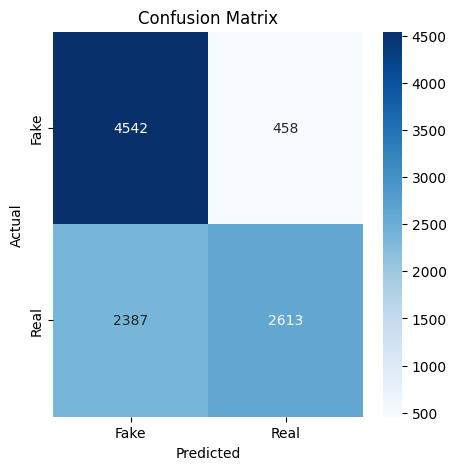

In [ ]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(5,5))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=["Fake", "Real"],
            yticklabels=["Fake", "Real"],
            cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


In [ ]:
model.save("vgg16_deepfake_model.h5")

In [ ]:
#Download model if wanted
from google.colab import files
files.download("vgg16_deepfake_model.h5")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
loss, accuracy = model.evaluate(val_gen)
print("Validation Accuracy:", accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 55s 174ms/step - accuracy: 0.8486 - loss: 0.3776
Validation Accuracy: 0.7166000008583069


# Testing Model

Saving photo.jpeg to photo (2).jpeg
User uploaded file "photo (2).jpeg"


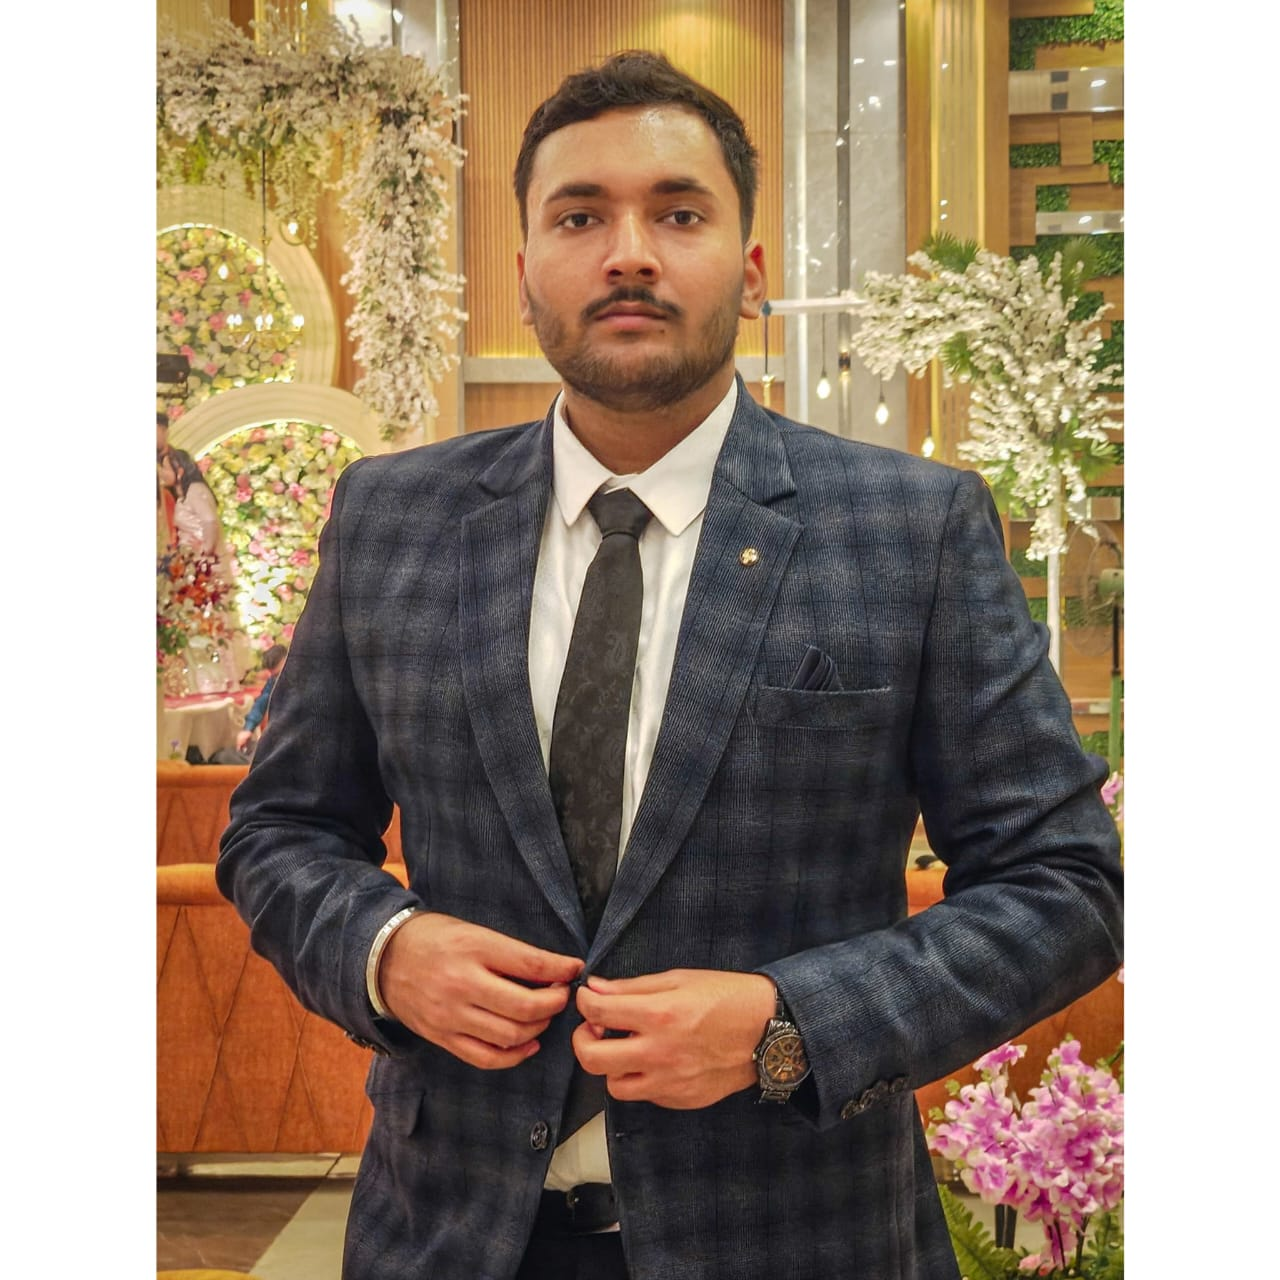

In [ ]:
from google.colab import files
from IPython.display import Image, display

# Step 1: Upload the file
uploaded = files.upload()

# Step 2: Loop through the uploaded files and display them
for filename in uploaded.keys():
    print(f'User uploaded file "{filename}"')
    #display(Image(filename))
    # Displays the image with a fixed width of 400 pixels
    display(Image(filename, width=400))

In [ ]:
from tensorflow.keras.preprocessing import image
import numpy as np

def predict_image(img_path):
    img = image.load_img(img_path, target_size=(224,224))
    img = image.img_to_array(img)
    img = img / 255.0
    img = np.expand_dims(img, axis=0)

    pred = model.predict(img)[0][0]

    if pred > 0.5:
        print("🟢 REAL FACE")
    else:
        print("🔴 FAKE FACE")

    print("Confidence:", pred)

# Replace with uploaded image name
predict_image("photo.jpeg")

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
🟢 REAL FACE
Confidence: 0.83799165
